In [ ]:
#Sagyndyk Aidyn
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


In [2]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Conv Layer 1
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        # Conv Layer 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        # FC layer
        self.fc1 = nn.Linear(32*7*7, num_classes)  # после 2 MaxPool, 28x28 → 14x14 → 7x7

    def forward(self, x):
        # Layer 1
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        # Layer 2
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)
        # Flatten
        x = x.view(x.size(0), -1)
        # FC
        x = self.fc1(x)
        return x

model = SimpleCNN()
print(model)


SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=10, bias=True)
)


In [3]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение на 5 эпох
for epoch in range(5):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.3f}, Accuracy: {100*correct/total:.2f}%")


Epoch 1, Loss: 0.356, Accuracy: 88.78%
Epoch 2, Loss: 0.157, Accuracy: 94.95%
Epoch 3, Loss: 0.122, Accuracy: 96.01%
Epoch 4, Loss: 0.103, Accuracy: 96.69%
Epoch 5, Loss: 0.089, Accuracy: 97.12%


Conv1 torch.Size([1, 16, 28, 28])


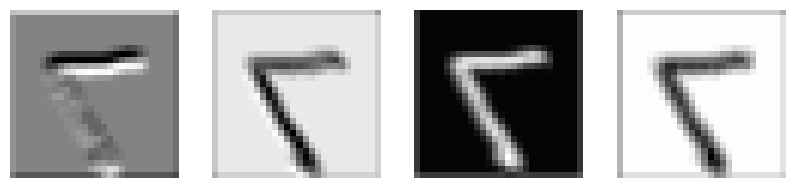

ReLU1 torch.Size([1, 16, 28, 28])


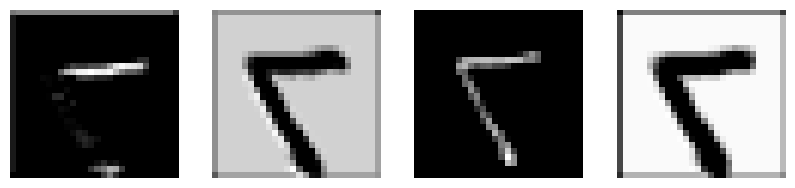

Pool1 torch.Size([1, 16, 14, 14])


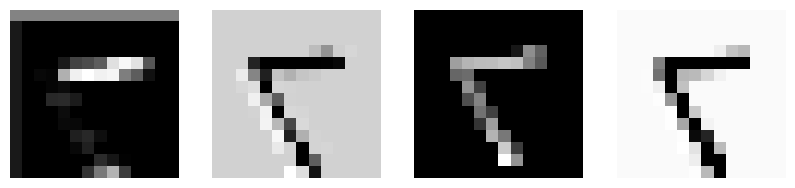

Conv2 torch.Size([1, 32, 14, 14])


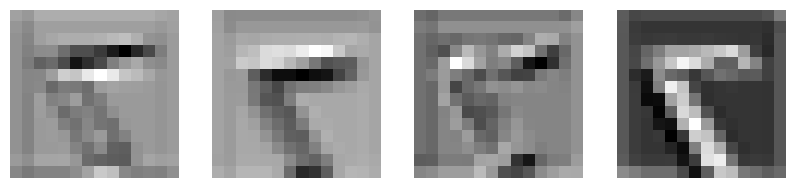

ReLU2 torch.Size([1, 32, 14, 14])


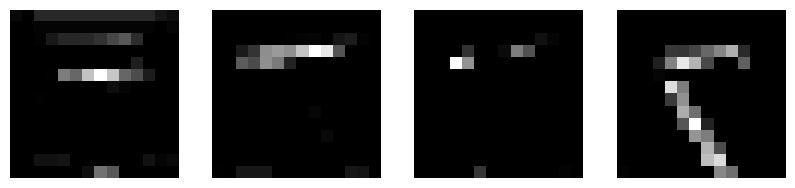

Pool2 torch.Size([1, 32, 7, 7])


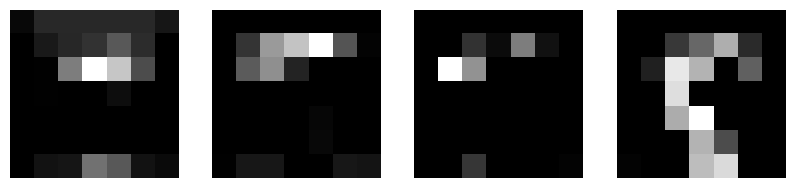

In [10]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

image, label = next(iter(test_loader))
single_image = image[0]  # [1,28,28]

single_image = single_image.to(device)

def visualize_feature_maps(model, image):
    model.eval()
    x = image.unsqueeze(0).to(device)  # batch=1
    conv1 = model.conv1(x)
    relu1 = F.relu(conv1)
    pool1 = F.max_pool2d(relu1, 2, 2)
    conv2 = model.conv2(pool1)
    relu2 = F.relu(conv2)
    pool2 = F.max_pool2d(relu2, 2, 2)

    layers = [conv1, relu1, pool1, conv2, relu2, pool2]
    layer_names = ['Conv1', 'ReLU1', 'Pool1', 'Conv2', 'ReLU2', 'Pool2']

    for l, name in zip(layers, layer_names):
        print(name, l.shape)
        fig, axes = plt.subplots(1, min(4, l.shape[1]), figsize=(10,3))
        if min(4, l.shape[1]) == 1:
            axes = [axes]
        for i in range(min(4, l.shape[1])):
            axes[i].imshow(l[0,i].detach().cpu(), cmap='gray')
            axes[i].axis('off')
        plt.show()

visualize_feature_maps(model, single_image)

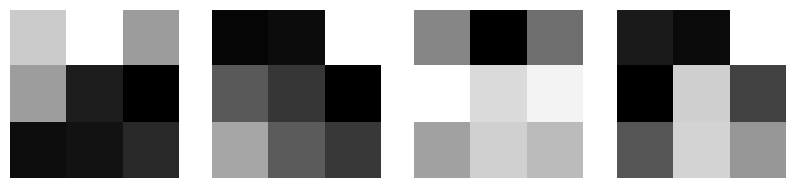

In [6]:
weights = model.conv1.weight.data.cpu()
fig, axes = plt.subplots(1,4, figsize=(10,3))
for i in range(4):
    axes[i].imshow(weights[i,0], cmap='gray')  # grayscale
    axes[i].axis('off')
plt.show()

In [7]:
model.eval()
correct = 0
total = 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")

Test Accuracy: 96.77%


1) Why do we typically use small kernels (like 3x3) instead of large ones (like 7x7 or 11x11) in modern architectures?
2) What is the difference between "Valid" and "Same" padding?
3) Why is ReLU preferred over Sigmoid in the hidden layers of a deep CNN?
4) What happens to the gradients when a ReLU unit outputs 0?
5) What is the primary purpose of Max Pooling? Does it have any trainable parameters?
6) How does pooling contribute to "translational invariance"?
7) If your model has high training accuracy but low test accuracy, what is happening, and how would you fix it?
8) How does Dropout help prevent overfitting in a CNN?
9) What features do the early layers of a CNN usually learn compared to the deeper layers?
10) Describe the concept of "Receptive Field" and how it changes as we go deeper into the network.

1. Требуют меньше параметров ,уменьшают вычисления, позволяют строить глубокие сети
2. Padding = 0. Ничего не добавляется вокруг изображения. Поэтому размер уменьшается.
Same padding Добавляется padding вокруг изображения. Цель — сохранить тот же размер.
3. В глубоких сетях возникает проблема: vanishing gradient (затухающий градиент).
Во время обучения используется backpropagation, где вычисляются градиенты. Если градиенты становятся очень маленькими, веса почти не обновляются.
4. нейрон не обновляет свои веса на этом шаге обучения. Иногда это может привести к dead neurons (нейрон всегда 0).
5. Уменьшает размер данных, Отавляет самые важные признаки, Берется максимальное значение в окне. Делает сеть устойчивой к небольшим сдвигам
6. Как pooling помогает translational invarianceTranslational invariance означает:сеть может распознавать объект, даже если он немного сдвинут.
Пример:Max Pooling берет максимум из области, поэтому небольшие сдвиги не сильно меняют результат.
7. overfitting Модель слишком хорошо запомнила training data, но плохо работает на новых данных. как исправить: добавить больше данных использовать Dropout использовать data augmentation
8. Dropout случайно выключает часть нейронов во время обучени Это заставляет сеть:не зависеть от конкретных нейронов учить более общие признаки
9. Ранние слои (Conv1)
Обычно находят: линии, края (edges), простые формы
Глубокие слои (Conv2, Conv3...)
Находят более сложные вещи: части объектов, комбинации линий, сложные формы
10. Receptive field — это часть изображения, которую "видит" нейрон. один нейрон не видит всё изображение, он видит только небольшой кусок
Этот кусок и называется receptive field.
